# MMT Relative Climate

## August 21, 2026
## Emily Zuetell

How does the climate and forecast relate to MMT? How does the distance to the MMT change and indicate risk?

In [1]:
# MMT vs forecast
import os
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd

import analysis_utils
import isku_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [2]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]
BETAS_PATH = os.environ["BETAS_PATH"]

# Climate Data
TAS_FORECAST_URI = os.environ["POREALLAS_TAS_FORECAST_URI"]
ERA5_URI = os.environ["POREALLAS_ERA5_URI"]
TAS_FORECAST_RAW = os.environ["POREALLAS_TAS_FORECAST_RAW_URI"]

In [3]:
# Impact Regions
_polygons = (
    gpd.read_parquet(os.path.join(DATA_DIR, IMPACT_REGION_POLYGONS))
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

# Socioeconomics
socioeconomics = xr.open_zarr(os.path.join(DATA_DIR, SOCIOECONOMICS_URI))
socioeconomics = socioeconomics.sel(year=2026)[
    ["pop0to4", "pop5to64", "pop65plus", "pop", "gdppc", "iso3"]
]

In [4]:
betas = xr.open_zarr(os.path.join(DATA_DIR, BETAS_PATH)).sel(age_cohort="age65plus")
mmt = betas["mmt"]

In [5]:
min_val = betas["beta"].min(dim="tas_bin")
is_min = betas["beta"] == min_val
central_tas_bin = betas["tas_bin"].where(is_min).median(dim="tas_bin", skipna=True)

In [6]:
era5 = xr.open_zarr(os.path.join(DATA_DIR, ERA5_URI)).groupby("time.month").mean()
era5_ir = isku_utils.grid_to_ir(era5.compute(), savefile=None)

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [7]:
diff = era5_ir["tas"] - 273.15 - central_tas_bin.mean(dim="sample")

In [8]:
_polygons_mmt = analysis_utils.xarray_to_gpd(
    central_tas_bin.mean(dim="sample"), _polygons
)

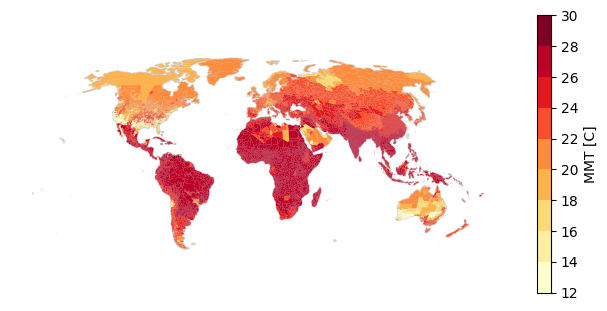

In [9]:
ax = analysis_utils.plot_single(
    _polygons_mmt,
    col="tas_bin",
    cm="YlOrRd",
    n_colors=10,
    vmin=12,
    vmax=30,
    sup_title="",
    cbar_label="MMT [C]",
)

In [10]:
_polygons_diff = analysis_utils.xarray_to_gpd(diff, _polygons)

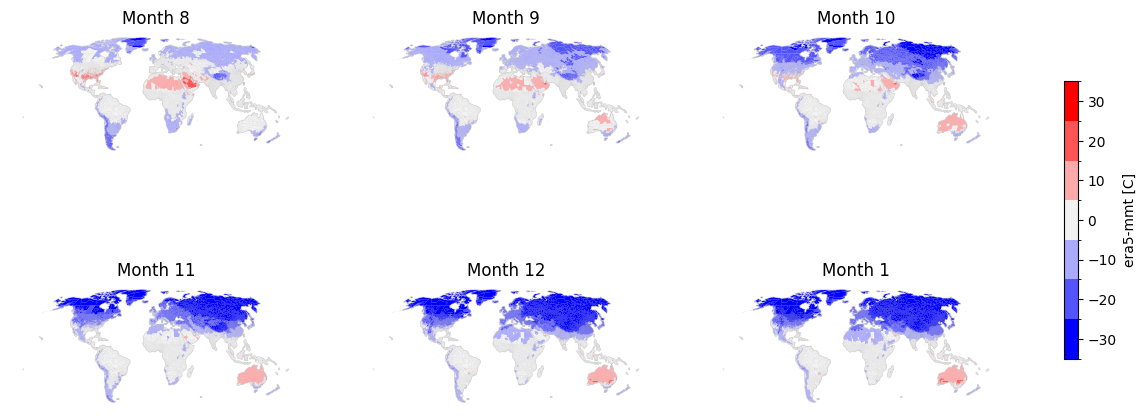

In [46]:
fig = analysis_utils.plot_monthly(
    _polygons_diff,
    col="value",
    cm="bwr",
    sup_title="",
    cbar_label="era5-mmt [C]",
    month_order=[8, 9, 10, 11, 12, 1],
)

In [13]:
forecast = xr.open_zarr(os.path.join(DATA_DIR, TAS_FORECAST_URI))
# Gridded to Impact Region
forecast_ir = isku_utils.grid_to_ir(forecast.mean(dim="number"), savefile=None)

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [14]:
diff_forecast = (
    forecast_ir["tas"].groupby("time.month").mean()
    - 273.15
    - central_tas_bin.mean(dim="sample")
)

In [15]:
_polygons_forecast = analysis_utils.xarray_to_gpd(diff_forecast, _polygons)

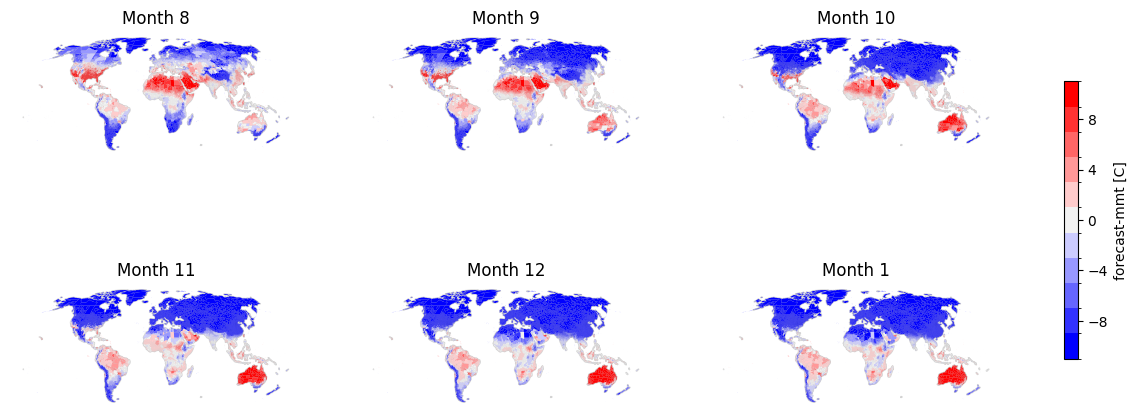

In [16]:
fig = analysis_utils.plot_monthly(
    _polygons_forecast,
    col="value",
    cm="bwr",
    vmin=-10,
    vmax=10,
    n_colors=13,
    sup_title="",
    cbar_label="forecast-mmt [C]",
    month_order=[8, 9, 10, 11, 12, 1],
)

In [19]:
_polygons_fc_all = analysis_utils.xarray_to_gpd(diff_forecast.mean(dim = 'month'), _polygons)

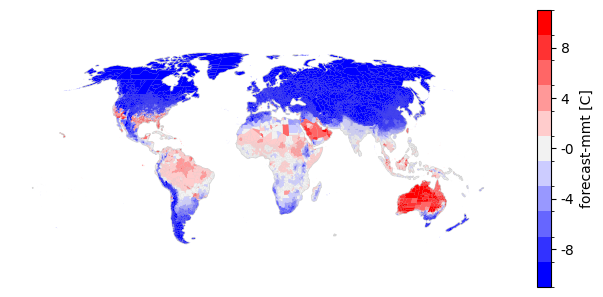

In [ ]:
ax = analysis_utils.plot_single(
    _polygons_fc_all,
    col="value",
    cm="bwr",
    vmin=-10,
    vmax=10,
    n_colors=13,
    sup_title="",
    cbar_label="Forecast-MMT [C]",
)

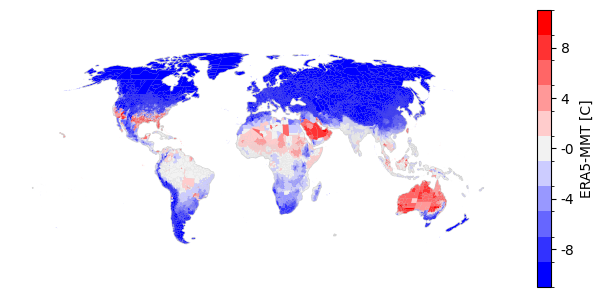

In [21]:
_polygons_era5_all = analysis_utils.xarray_to_gpd(diff.mean(dim = 'month'), _polygons)
ax = analysis_utils.plot_single(
    _polygons_era5_all,
    col="value",
    cm="bwr",
    vmin=-10,
    vmax=10,
    n_colors=13,
    sup_title="",
    cbar_label="ERA5-MMT [C]",
)

In [30]:
_polygons_era5_all = analysis_utils.xarray_to_gpd((diff_forecast.mean(dim = 'month')**2-diff.mean(dim = 'month')**2), _polygons)
ax = analysis_utils.plot_monthly(
    _polygons_era5_all,
    col="value",
    cm="bwr",
    vmin=-15,
    vmax=15,
    n_colors=13,
    sup_title="",
    cbar_label="(Forecast-MMT)**2 - (ERA5-MMT)**2 [C]",
)

KeyError: 'month'

In [27]:
diff_forecast.mean(dim='month').where(diff_forecast.mean(dim='month').compute() > 0, drop=True)

<xarray.DataArray (region: 5937)> Size: 47kB
dask.array<where, shape=(5937,), dtype=float64, chunksize=(5937,), chunktype=numpy.ndarray>
Coordinates:
  * region      (region) object 47kB 'ABW' 'AGO.14.120' ... 'ZWE.8.41'
    age_cohort  <U9 36B 'age65plus'
Attributes: (12/38)
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      64800
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    ...                                       ...
    poreallas_sim_start_year:                 2007
    poreallas_sim_stop_year:                  2027
    poreallas_ref_uri:                        /home/emily_zuetell/projects/po...
    poreallas_hist_uri:                       /home/emily_zuetell/projects/po...
    poreallas_sim_uri:                        /home/emily_zuetell/projects/po...
    units_metadata:                           temperature: unknown

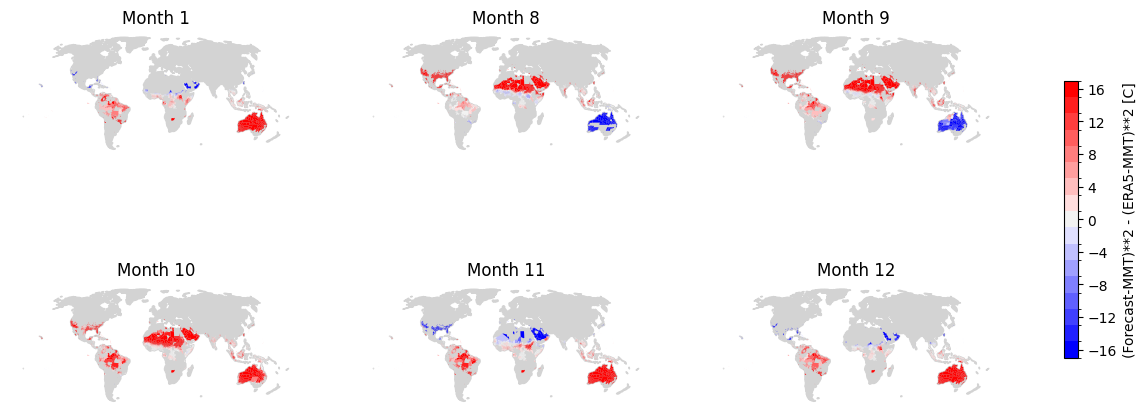

In [31]:
_polygons_era5_all = analysis_utils.xarray_to_gpd((diff_forecast.where(diff_forecast.compute() > 0, drop=True)**2-diff.mean(dim='month').where(diff.mean(dim='month').compute() > 0, drop=True)**2), _polygons)
ax = analysis_utils.plot_monthly(
    _polygons_era5_all,
    col="value",
    cm="bwr",
    vmin=-15,
    vmax=15,
    n_colors=13,
    sup_title="",
    cbar_label="(Forecast-MMT)**2 - (ERA5-MMT)**2 [C]",
)

In [70]:
com = diff_forecast / diff
_polygons_com = analysis_utils.xarray_to_gpd(com, _polygons)

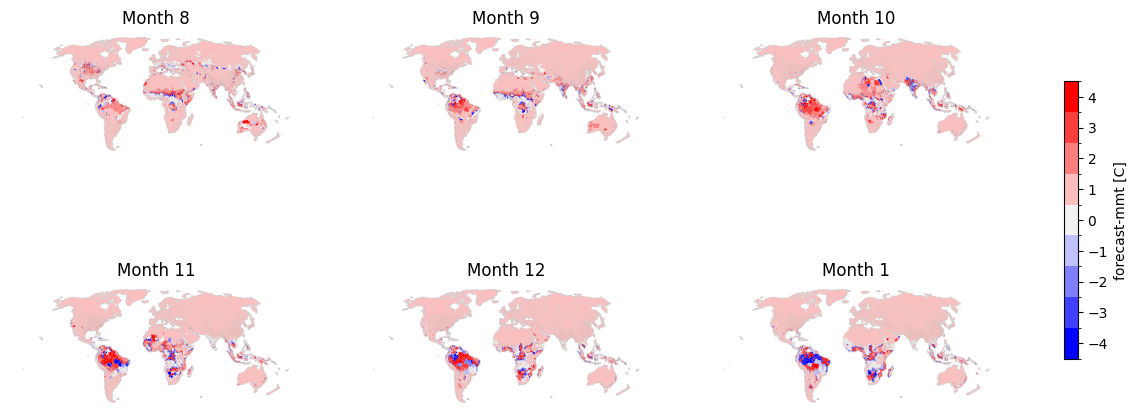

In [71]:
fig = analysis_utils.plot_monthly(
    _polygons_com,
    col="value",
    cm="bwr",
    sup_title="",
    cbar_label="forecast-mmt [C]",
    month_order=[8, 9, 10, 11, 12, 1],
)